Problem: phân loại Email spam và not spam
Mục đích:

Xây dựng hệ thống tự động phát hiện spam và not spam, giúp lọc spam đơn giản

Dataset: nguồnUCI Machine Learning Repository

https://archive.ics.uci.edu/dataset/94/spambase

Quy trình thực hiện

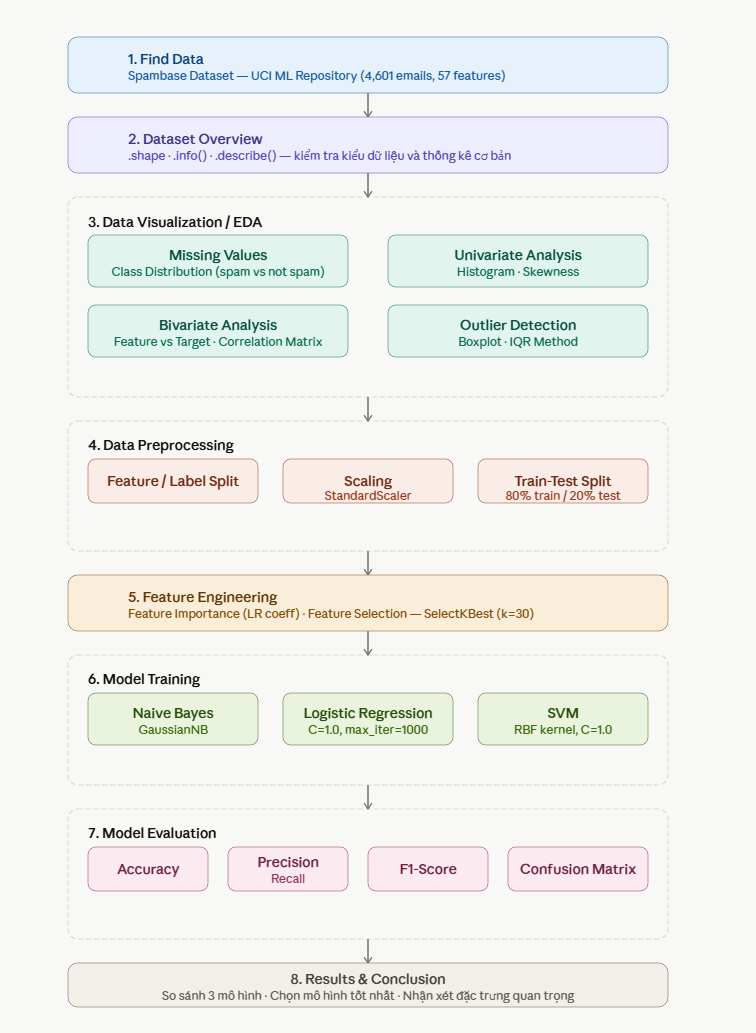

tìm dữ liệu

In [ ]:
import pandas as pd
df = pd.read_csv('spambase.data', header=None)
print(df.head())

     0     1     2    3     4     5     6     7     8     9   ...    48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.01   
3  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   
4  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   

      49   50     51     52     53     54   55    56  57  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278   1  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028   1  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259   1  
3  0.137  0.0  0.137  0.000  0.000  3.537   40   191   1  
4  0.135  0.0  0.135  0.000  0.000  3.537   40   191   1  

[5 rows x 58 columns]


Tổng quan về tập dữ liệu

In [ ]:
df.shape

(4601, 58)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       4601 non-null   float64
 1   1       4601 non-null   float64
 2   2       4601 non-null   float64
 3   3       4601 non-null   float64
 4   4       4601 non-null   float64
 5   5       4601 non-null   float64
 6   6       4601 non-null   float64
 7   7       4601 non-null   float64
 8   8       4601 non-null   float64
 9   9       4601 non-null   float64
 10  10      4601 non-null   float64
 11  11      4601 non-null   float64
 12  12      4601 non-null   float64
 13  13      4601 non-null   float64
 14  14      4601 non-null   float64
 15  15      4601 non-null   float64
 16  16      4601 non-null   float64
 17  17      4601 non-null   float64
 18  18      4601 non-null   float64
 19  19      4601 non-null   float64
 20  20      4601 non-null   float64
 21  21      4601 non-null   float64
 22  

In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


Khám phá dữ liệu (EDA)

Phát hiện dữ liệu thiếu

Kiểm tra toàn bộ vị trí thiếu

In [ ]:
df.isnull()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4597,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4598,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4599,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Kiểm tra theo cột

In [ ]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


phân bổ theo lớp

In [ ]:
target = df.iloc[:, -1]
print(target.value_counts())

57
0    2788
1    1813
Name: count, dtype: int64


<Axes: xlabel='57'>

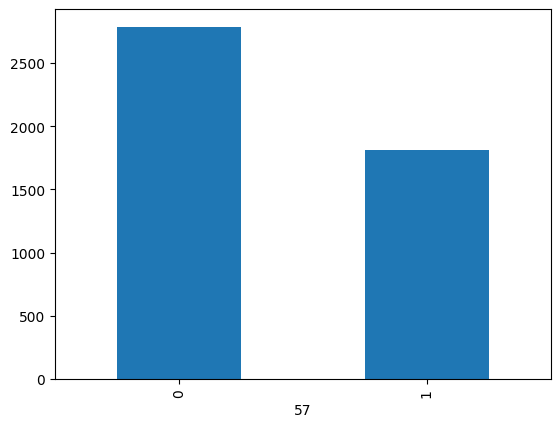

In [ ]:
target.value_counts().plot(kind='bar')

Biểu đồ tần số

<Axes: >

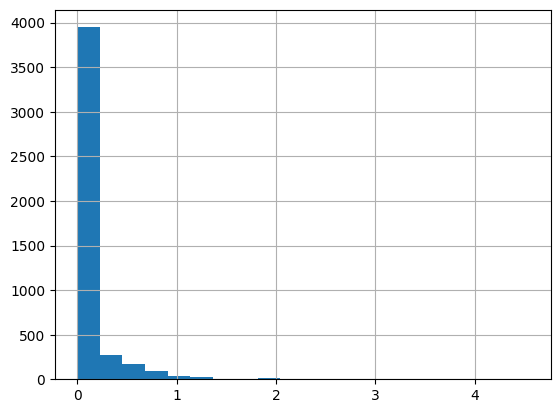

In [ ]:
df[0].hist(bins=20)

độ lệch

In [ ]:
skewness =df.skew()
print(skewness.sort_values(ascending=False).head(10))

53    31.062064
55    30.764993
37    28.263216
3     26.227744
54    23.761923
50    21.083545
46    19.867691
47    19.720446
43    18.771515
51    18.658004
dtype: float64


biến đổi 2 chiều - đặc trưng so với mục tiêu

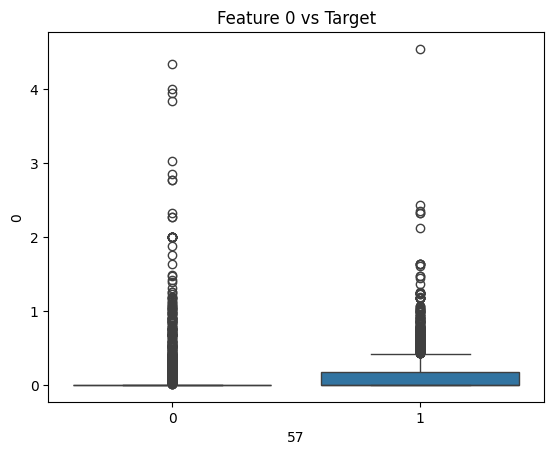

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df[57], y=df[0])
plt.title("Feature 0 vs Target")
plt.show()

ma trận tương quan

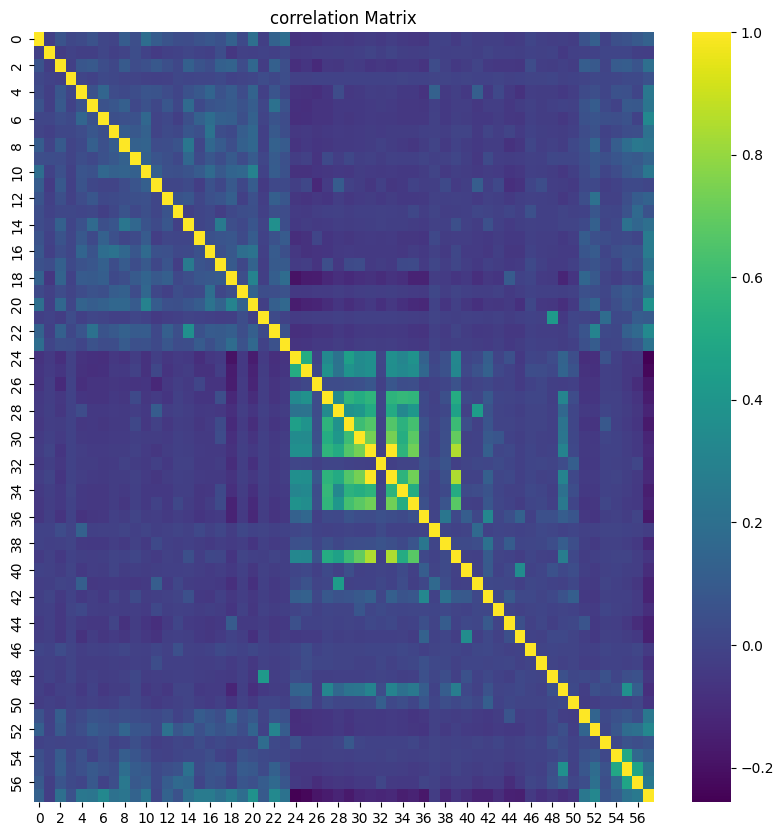

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), cmap='viridis')
plt.title("correlation Matrix")
plt.show()


biểu đồ hợp

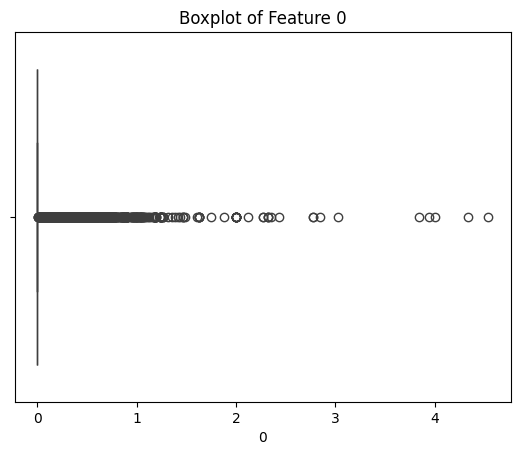

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df[0])

plt.title("Boxplot of Feature 0")
plt.show()

IQR

In [ ]:
Q1 = df[53].quantile(0.25)
Q3 = df[53].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[53] < lower_bound) | (df[53] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 750


Feature/label split ( tách đặc trưng/nhãn)

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.shape)
print(y.shape)

(4601, 57)
(4601,)


Scaling/chuẩn hóa dữ liệu

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(4601, 57)


chia thành tập train và test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Feature Importance

Top 10 Important Features:
[51 52  6 15 54 55 56 20 24 18]


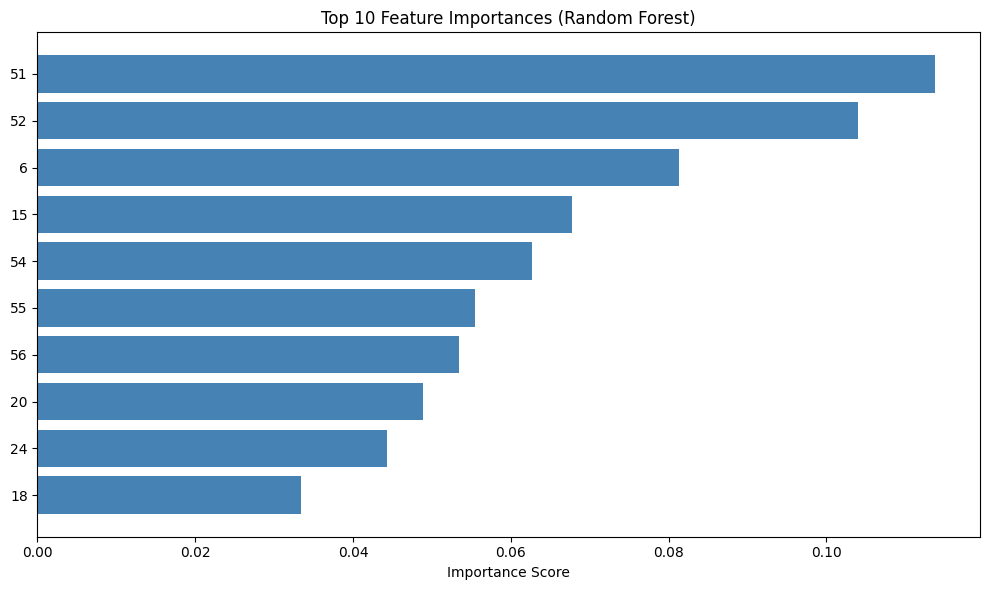

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# train random Forest
cf = RandomForestClassifier(n_estimators=100, random_state=42)
cf.fit(X_train, y_train)
# Feature Iportance
importances = cf.feature_importances_
# top 10 Feature
indices = importances.argsort()[-10:][::-1]
print("Top 10 Important Features:")
print(indices)
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices][::-1], color='steelblue')
plt.yticks(range(10), [str(i) for i in indices[::-1]])
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# **Huấn luyện mô hình và kết quả thực nghiệm**

## 1.   *Huấn luyện mô hình Naive Bayes*


### Chuẩn bị dữ liệu:

  X = df.drop("label", axis=1) # đặc trưng ( 57 feature trong Spambase dataset)

  y = df["label"] # nhãn: 0 = Ham, 1 = spam

*   X: mỗi email được biểu diễn bằng vector đặc trưng ( tần suất từ, tỷ lệ ký tự in hoa, dấu chấm than,...)

*  y: nhãn thực tế ( Ham và Spam)
### chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Dữ liệu chia thành 80% train và 20% test

stratify=y để giữ tỷ lệ Spam/Ham đồng đều cho cả train và test

Huấn luyện mô hình Naive Bayes

nb = MultinomialNB()

nb.fit(X_train, y_train)

Dùng Multinomial Naive Bayes - thích hợp cho dữ liệu đếm/tần suất ( bag-of-words)

Áp dụng định lý Bayes:

trong code, fit() sẽ:

Tính xác suất tiên nghiệm

Tính xác suất có điều kiện

lưu lại để dự đoán

*   Tính xác suất tiên nghiệm
*   Tính xác suất có điều kiện
*   lưu lại để dự đoán
### Dự đoán
y_pred_nb = nb.predict(X_test)

với mỗi email mới:
*   Tính xác suất thuộc lớp Ham và Spam
*   chọn lớp có xác suất lớn nhất
### Đánh giá mô hình
print("Accuracy:", accuracy_sore(y_test, y_pred_nb))

print("n\classification Report:\n", classification report(y_test, y_pred_nb))


*   Accuracy: tỷ lệ đúng
*   classification Report: Precision, Recall, F1-score cho từng lớp (Ham/Spam)
### ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

xtichlabels = ["Ham", "Spam"]

ytichlabels = ["Ham", "Spam"]
Hiển thị số lượng đúng/sai:


*   TP ( True Positive): Thư rác được dự đoán là sai

*   TN ( True Negative): Ham được dự đoán sai
*   FP ( False Positive): Ham được dự đoán là nhầm lẫn với thư rác


*   FN ( False Negative): Thư rác bị nhầm lẫn thành Ham










    




Huấn luyện mô hình Naive Bayes

Accuracy: 0.7763300760043431

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.82       558
           1       0.72      0.71      0.71       363

    accuracy                           0.78       921
   macro avg       0.77      0.76      0.77       921
weighted avg       0.78      0.78      0.78       921



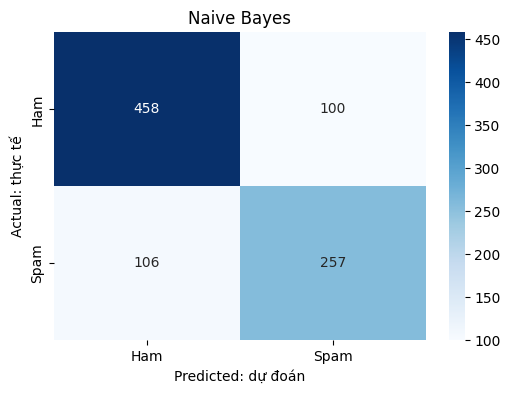

In [ ]:
# Naive Bayes
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chọn đặc trưng (X) và nhãn (y)
X = df.drop(57, axis=1)
y = df[57]

# 2. Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Khởi tạo và huấn luyện Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

# 4. Dự đoán
y_pred_nb = nb.predict(X_test)

# 5. Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# 6. Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted: dự đoán")
plt.ylabel("Actual: thực tế")
plt.title("Naive Bayes")
plt.show()

### Huấn luyện mô hình Logistic Regression
Khởi tạo mô hình Logistic Regression

log_reg = LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced")
Trong đó:

 max_iter=1000: số vòng lặp tối đa cho thuật toán tối ưu

 solver="liblinear": bộ giải tối ưu, liblinear tốt cho bộ dữ liệu nhỏ/ nhị phân và hỗ trợ penalty L1/L2.

 class_weight="balanced": tự động cân bằng trọng số cho các lớp theo tần suất

 => giúp mô hình không bỏ qua lớp ít mẫu







Huấn luyện mô hình logistic regression

Accuracy: 0.9261672095548317

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       558
           1       0.89      0.93      0.91       363

    accuracy                           0.93       921
   macro avg       0.92      0.93      0.92       921
weighted avg       0.93      0.93      0.93       921



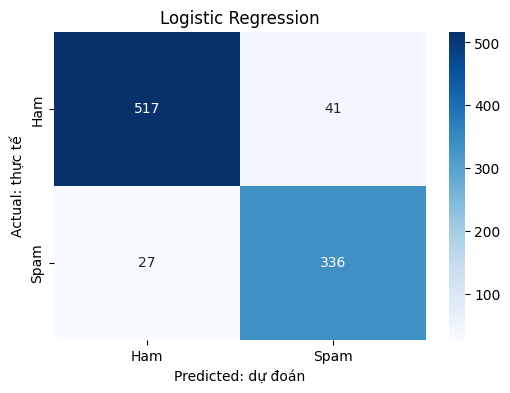

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# Khởi tạo mô hình Logistic Regression
log_reg = LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced")

# Huấn luyện mô hình trên tập train
log_reg.fit(X_train, y_train)

# Dự đoán nhãn cho tập test
y_pred_lr = log_reg.predict(X_test)

# In tỉ lệ dự đoán đúng
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

# In báo cáo Precision, Recall, F1-Score cho từng lớp
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Tính ma trận nhầm lẫn
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Vẽ ma trận nhầm lẫn dạng heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])

# Đặt nhãn trục x, y và tiêu đề
plt.xlabel("Predicted: dự đoán")
plt.ylabel("Actual: thực tế")
plt.title("Logistic Regression")
plt.show()

Results & Conclusion

=== KẾT QUẢ SO SÁNH ===
              Model  Accuracy  Precision   Recall  F1-Score
        Naive Bayes  0.776330   0.719888 0.707989  0.713889
Logistic Regression  0.926167   0.891247 0.925620  0.908108

🏆 Mô hình tốt nhất: Logistic Regression
   Accuracy : 0.9262
   Precision: 0.8912
   Recall   : 0.9256
   F1-Score : 0.9081


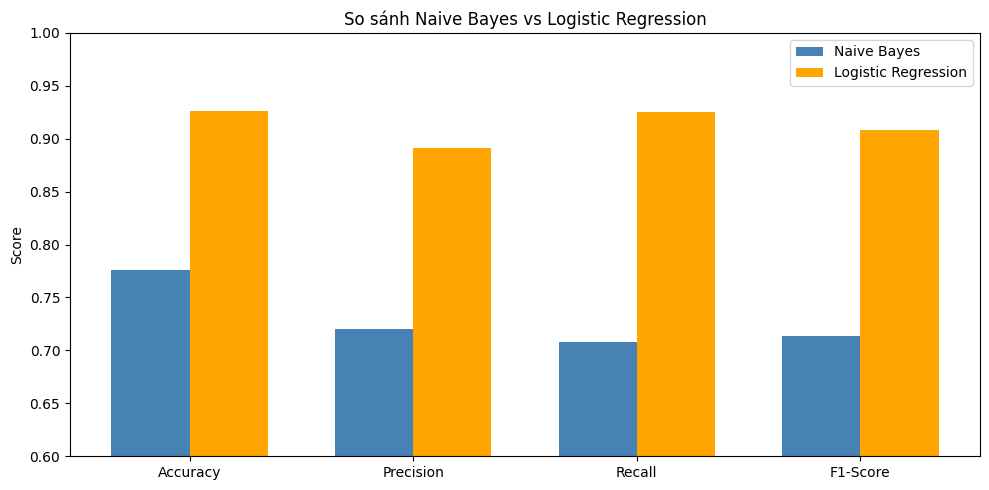

In [ ]:
# Results & Conclusion
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Bảng so sánh 2 mô hình
results = pd.DataFrame({
    'Model':     ['Naive Bayes', 'Logistic Regression'],
    'Accuracy':  [accuracy_score(y_test, y_pred_nb),  accuracy_score(y_test, y_pred_lr)],
    'Precision': [precision_score(y_test, y_pred_nb), precision_score(y_test, y_pred_lr)],
    'Recall':    [recall_score(y_test, y_pred_nb),    recall_score(y_test, y_pred_lr)],
    'F1-Score':  [f1_score(y_test, y_pred_nb),        f1_score(y_test, y_pred_lr)]
})

print("=== KẾT QUẢ SO SÁNH ===")
print(results.to_string(index=False))

# Mô hình tốt nhất
best = results.loc[results['F1-Score'].idxmax()]
print(f"\n🏆 Mô hình tốt nhất: {best['Model']}")
print(f"   Accuracy : {best['Accuracy']:.4f}")
print(f"   Precision: {best['Precision']:.4f}")
print(f"   Recall   : {best['Recall']:.4f}")
print(f"   F1-Score : {best['F1-Score']:.4f}")

# Vẽ biểu đồ so sánh
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results.iloc[0][metrics], width, label='Naive Bayes', color='steelblue')
ax.bar(x + width/2, results.iloc[1][metrics], width, label='Logistic Regression', color='orange')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Score')
ax.set_title('So sánh Naive Bayes vs Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()